In [1]:
import pandas as pd

df_modis = pd.read_csv(
    "../output/NDVI_modis_RI_2016_2026.csv",
    parse_dates=["date"]
)

df_s2 = pd.read_csv(
    "../output/NDVI_S2_RI_2016_2026.csv",
    parse_dates=["date"]
)

In [2]:
df_modis = df_modis.rename(
    columns={"mean_ndvi": "ndvi_modis"}
)

df_s2 = df_s2.rename(
    columns={"mean_ndvi_s2": "ndvi_s2"}
)

In [3]:
df_s2["date"] = pd.to_datetime(
    df_s2["date"]
).dt.normalize()

In [4]:
df_train = pd.merge(
    df_modis,
    df_s2,
    on="date",
    how="inner"
)

In [5]:
df_train

,date,ndvi_modis,ndvi_s2
0,2016-05-18,0.842,0.836
1,2016-06-07,0.855,0.847
2,2016-06-27,0.853,0.841
3,2016-07-07,0.846,0.849
4,2016-07-17,0.869,0.836
...,...,...,...
231,2026-03-17,0.653,0.535
232,2026-04-08,0.694,0.583
233,2026-04-16,0.822,0.687
234,2026-04-21,0.802,0.810


# LM with scikit

In [6]:
from sklearn.linear_model import LinearRegression

X = df_train[["ndvi_modis"]]
y = df_train["ndvi_s2"]

model = LinearRegression()

model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


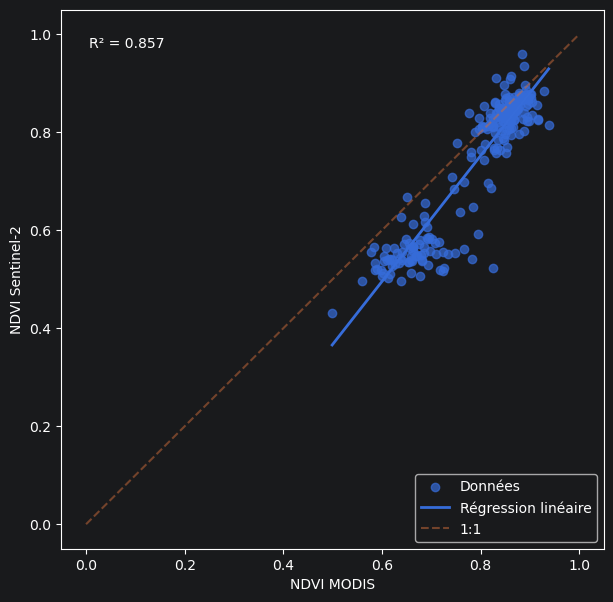

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

# variables
X = df_train["ndvi_modis"]
y = df_train["ndvi_s2"]

# prédictions du modèle
y_pred = model.predict(df_train[["ndvi_modis"]])

# tri pour une ligne propre
order = np.argsort(X)

r2 = r2_score(y, y_pred)



# figure
fig, ax = plt.subplots(figsize=(7,7))

# points
ax.scatter(
    X,
    y,
    alpha=0.7,
    label="Données"
)

# droite de régression
ax.plot(
    X.iloc[order],
    y_pred[order],
    linewidth=2,
    label="Régression linéaire"
)

ax.text(
    0.05,
    0.95,
    f"R² = {r2:.3f}",
    transform=ax.transAxes,
    va="top"
)

ax.plot(
   [0,1],
   [0,1],
   linestyle="--",
   alpha=0.5,
   label="1:1"
)

ax.set_xlabel("NDVI MODIS")
ax.set_ylabel("NDVI Sentinel-2")

ax.legend()

plt.show()

In [8]:
df_modis["ndvi_s2_pred"] = model.predict(
    df_modis[["ndvi_modis"]]
)

In [9]:
dates_s2 = set(df_s2["date"])

In [10]:
df_modis["is_real_s2"] = df_modis["date"].isin(dates_s2)

df_inferred = df_modis[~df_modis["is_real_s2"]]

In [11]:
df_train["pred_train"] = model.predict(
    df_train[["ndvi_modis"]]
)

df_train["residual"] = (
    df_train["ndvi_s2"]
    - df_train["pred_train"]
)

In [12]:
sigma = df_train["residual"].std()

## make a new dataset (real s2 + inferred pS2 when no s2 point available)

In [13]:
df_fused = df_modis[["date", "ndvi_s2_pred"]].copy()

In [14]:
df_fused = df_fused.merge(
    df_s2[["date", "ndvi_s2"]],
    on="date",
    how="left"
)

In [15]:
df_fused["ndvi_final"] = (
    df_fused["ndvi_s2"]
    .fillna(df_fused["ndvi_s2_pred"])
)

In [16]:
df_fused["source"] = np.where(
    df_fused["ndvi_s2"].notna(),
    "S2",
    "MODIS_LM"
)

In [17]:
from scipy.signal import savgol_filter

df_fused["ndvi_smooth"] = savgol_filter(
    df_fused["ndvi_final"],
    window_length=21,
    polyorder=3
)

In [18]:
df_fused["lower"] = df_fused["ndvi_smooth"] - sigma
df_fused["upper"] = df_fused["ndvi_smooth"] + sigma

In [19]:
df_fused["lower_smooth"] = savgol_filter(
    df_fused["lower"],
    window_length=21,
    polyorder=3
)

df_fused["upper_smooth"] = savgol_filter(
    df_fused["upper"],
    window_length=21,
    polyorder=3
)

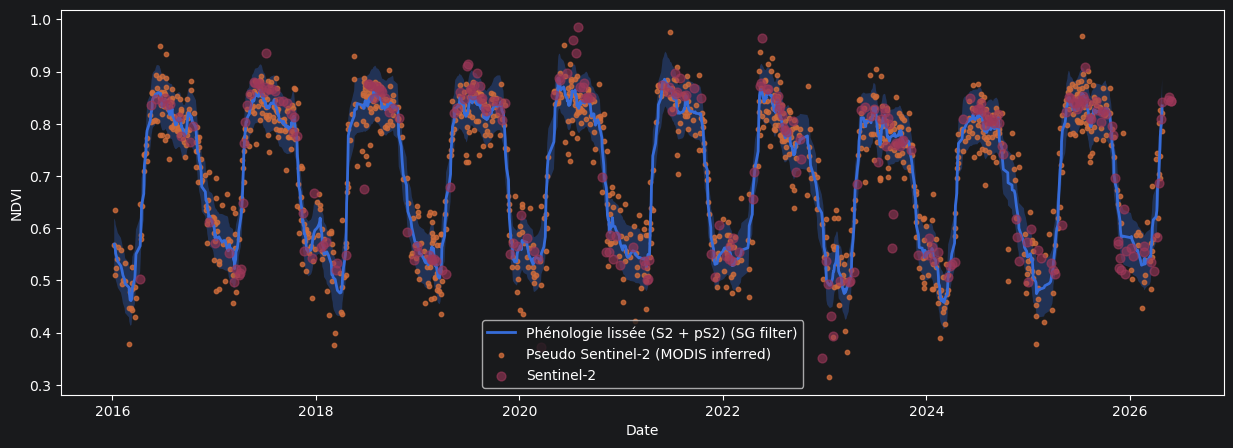

In [20]:
fig, ax = plt.subplots(figsize=(15,5))

#plt.style.use("default")

ax.fill_between(
    df_fused["date"],
    df_fused["lower_smooth"],
    df_fused["upper_smooth"],
    alpha=0.3,
    #label="Incertitude"
)

ax.plot(
    df_fused["date"],
    df_fused["ndvi_smooth"],
    linewidth=2,
    label="Phénologie lissée (S2 + pS2) (SG filter)"
)

# points inférés uniquement
ax.scatter(
    df_inferred["date"],
    df_inferred["ndvi_s2_pred"],
    s=10,
    alpha=0.8,
    label="Pseudo Sentinel-2 (MODIS inferred)"
)


# points Sentinel réels
ax.scatter(
    df_s2["date"],
    df_s2["ndvi_s2"],
    s=40,
    zorder=4,
    alpha=0.6,
    label="Sentinel-2"
)

ax.set_ylabel("NDVI")
ax.set_xlabel("Date")


# ax.set_xlim(
#     pd.Timestamp("2018-01-01"),
#     pd.Timestamp("2020-12-31")
# )


ax.legend()
plt.show()

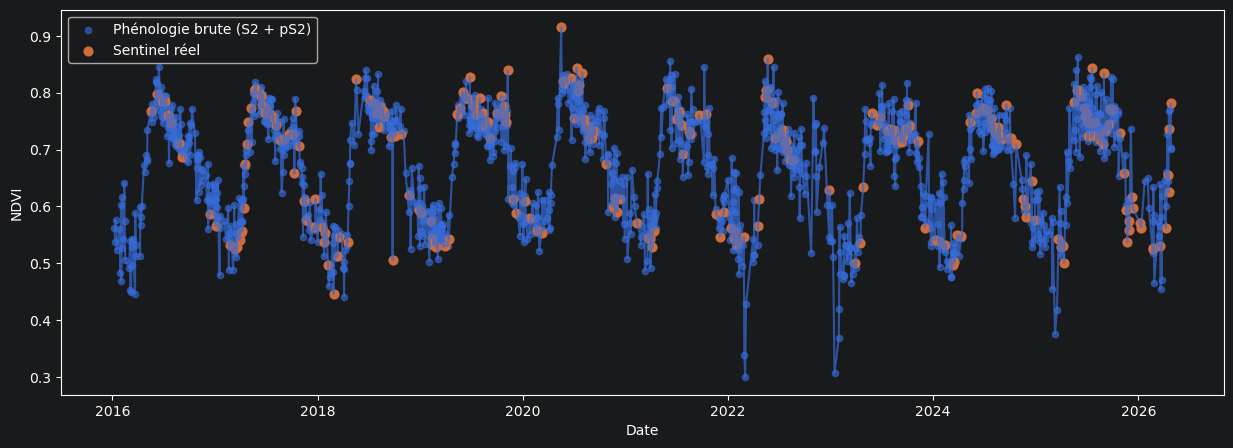

In [21]:
fig, ax = plt.subplots(figsize=(15,5))

# pseudo Sentinel inféré
ax.scatter(
    df_fused["date"],
    df_fused["ndvi_final"],
    s=20,
    alpha=0.6,
    label="Phénologie brute (S2 + pS2)"
)

# vraies observations Sentinel
ax.scatter(
    df_fused["date"],
    df_fused["ndvi_s2"],
    s=40,
    label="Sentinel réel"
)

# ligne continue de phénologie
ax.plot(
    df_fused["date"],
    df_fused["ndvi_final"],
    alpha=0.7
)


ax.set_xlabel("Date")
ax.set_ylabel("NDVI")

ax.legend()

# ax.set_xlim(
#     pd.Timestamp("2018-01-01"),
#     pd.Timestamp("2020-12-31")
# )


plt.show()

# Export the phenology

In [22]:
df_export = df_fused[["date", "ndvi_final", "ndvi_smooth", "source"]]
print(df_export)

           date  ndvi_final  ndvi_smooth    source
0    2016-01-08    0.561419     0.540529  MODIS_LM
1    2016-01-12    0.538414     0.546479  MODIS_LM
2    2016-01-13    0.576059     0.550826  MODIS_LM
3    2016-01-17    0.523774     0.553697  MODIS_LM
4    2016-01-26    0.560373     0.555218  MODIS_LM
...         ...         ...          ...       ...
1518 2026-04-21    0.736000     0.726980        S2
1519 2026-04-24    0.770560     0.733218  MODIS_LM
1520 2026-04-25    0.702589     0.736006  MODIS_LM
1521 2026-04-26    0.781000     0.734843        S2
1522 2026-04-27    0.700498     0.729230  MODIS_LM

[1523 rows x 4 columns]


In [23]:
df_export.to_csv("../output/phenology_2016_2026_RI.csv", index=False, float_format="%.3f")